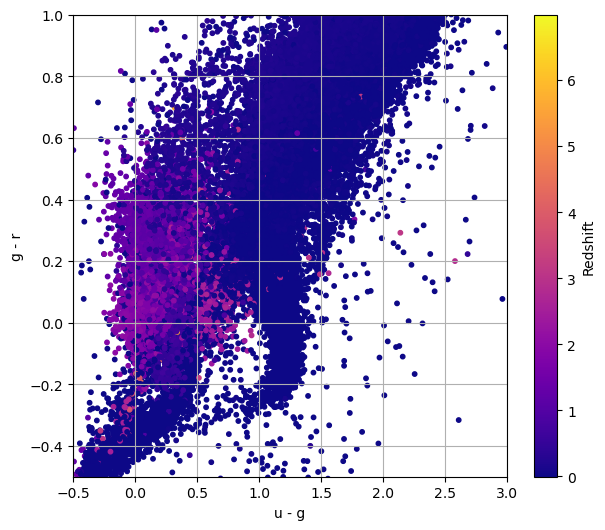

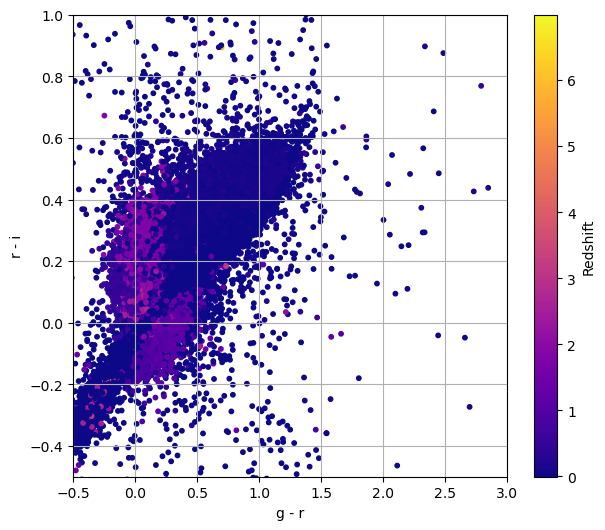

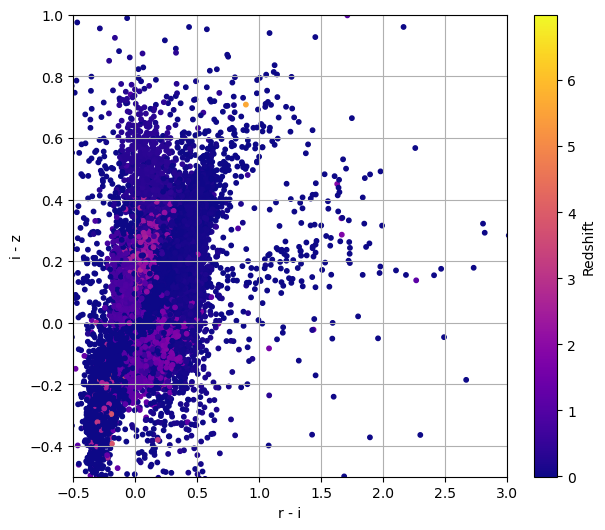

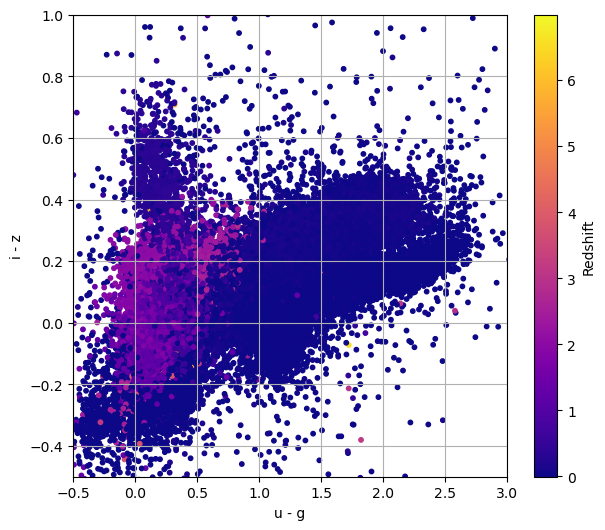

          objid     specobjid          ra       dec         u         g  \
0  1.240000e+18  3.240000e+17  184.950869  0.733068  18.87062  17.59612   
1  1.240000e+18  3.250000e+17  185.729201  0.679704  19.59560  19.92153   
2  1.240000e+18  3.240000e+17  185.687690  0.823480  19.26421  17.87891   
3  1.240000e+18  2.880000e+18  185.677904  0.768362  19.49739  17.96166   
4  1.240000e+18  2.880000e+18  185.814763  0.776940  18.31519  16.83033   

          r         i         z  run  ...   expAB_g   expAB_r   expAB_i  \
0  17.11245  16.83899  16.70908  756  ...  0.518483  0.520474  0.508502   
1  20.34448  20.66213  20.59599  756  ...  0.531728  0.403072  0.999874   
2  17.09593  16.65159  16.35329  756  ...  0.743386  0.770897  0.778642   
3  17.41269  17.20545  17.11567  756  ...  0.787760  0.745611  0.399718   
4  16.26352  16.06320  15.97527  756  ...  0.834450  0.723526  0.712259   

    expAB_z  redshift   class    u - g    g - r    r - i    i - z  
0  0.488969  0.041691  GALAXY 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/SDSS_DR18.csv')

#new_names = {'objid' : 'Object ID', 'specobjid' : 'SpecObj ID', 'ra' : 'Right Ascension', 'dec' : 'Declination'}
#df.rename(columns = new_names, inplace = True)

# Exploratory Data Analysis - See visually if galaxies with higher redshift tend to have brighter colours.

df['u - g'] = df['u'] - df['g']
df['g - r'] = df['g'] - df['r']
df['r - i'] = df['r'] - df['i']
df['i - z'] = df['i'] - df['z']

# Create pairs

pairs = [('u - g', 'g - r'), ('g - r', 'r - i'), ('r - i', 'i - z'), ('u - g', 'i - z')]

# Each pair portrays a splice within the colour spectrum in a descending order of brightness.
# Each graph will then be coloured to far into the past the observation is.

limits = [((-0.5, 3.0), (-0.5, 1.5)), ((-0.5, 1.5), (-0.5, 0.8)), ((-0.5, 0.8),(-0.5, 0.8)), ((-0.5, 3.0),(-0.5, 1.0))]

# Graph creation of all pairs seperately via looping
# These graphs are merely for exploration/visualisation, showing correlations.

for shift_x, shift_y in pairs:
    plt.figure(figsize=(7,6))
    plt.scatter(df[shift_x], df[shift_y], c=df['redshift'], cmap='plasma', s=10)
    plt.xlabel(shift_x)
    plt.ylabel(shift_y)
    plt.colorbar(label='Redshift')

    for cut_x, cut_y in limits:
        plt.xlim(cut_x)
        plt.ylim(cut_y)

    plt.grid(True)
    plt.show()


print(df.head())
print(df.shape)